In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client
from sklearn.model_selection import train_test_split

load_dotenv()
url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")
supabase = create_client(url, key)

all_rows = []
start = 0
batch_size = 1000

while True:
    response = supabase.table("telco_churn").select("*").range(start, start + batch_size - 1).execute()
    if not response.data:
        break
    all_rows.extend(response.data)
    start += batch_size

df = pd.DataFrame(all_rows)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["Churn"], random_state=42
)

eda_df = df_train.copy()
print(eda_df.shape)

(5634, 21)


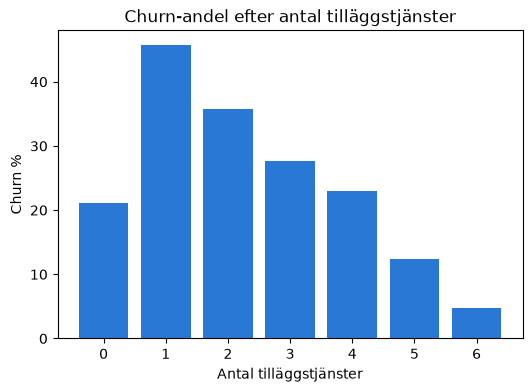

In [3]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

eda_df["num_services"] = (eda_df[service_cols] == "Yes").sum(axis=1)

churn_by_services = eda_df.groupby("num_services")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(churn_by_services.index.astype(str), churn_by_services.values, color="#2a78d6")
ax.set_xlabel("Antal tilläggstjänster")
ax.set_ylabel("Churn %")
ax.set_title("Churn-andel efter antal tilläggstjänster")
plt.show()